# Phase 4 & RQ3: Predictive Modeling & Out-of-Sample Evaluation
This notebook tests whether specifying Non-linear Random Forest architectures with **FinBERT states** and **Regime classification categorical variables** improves predictive capability directly over classical Macroeconomic specifications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Integrated Capstone Database

In [2]:
DATA_PATH = "../Dataset/integrated_panel_with_corrected_regimes.csv"
print(f"Loading data from {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
df['Month'] = pd.to_datetime(df['Month'])

df.head()

Loading data from ../Dataset/integrated_panel_with_corrected_regimes.csv


,Month,Sub-Nbhood,Beds,Median_Sale_Price,Avg_Sale_Price,Transaction_Count,FEDFUNDS,UNRATE,PCE_YOY,MORTGAGE_SPREAD,FinBERT_Hawkish,FinBERT_Dovish,FinBERT_Neutral,Net_Hawkishness,Regime
0,2016-01-01,Battery Park City,3.0,2120271.0,2120271.0,2,0.34,4.8,3.408554,3.5325,0.0,0.0,1.0,0.0,Expansion / Normalization
1,2016-01-01,Battery Park City,4.0,5600375.0,5600375.0,1,0.34,4.8,3.408554,3.5325,0.0,0.0,1.0,0.0,Expansion / Normalization
2,2016-01-01,Central Harlem,1.0,423680.0,475985.0,4,0.34,4.8,3.408554,3.5325,0.0,0.0,1.0,0.0,Expansion / Normalization
3,2016-01-01,Central Harlem,2.0,1017231.0,897077.0,3,0.34,4.8,3.408554,3.5325,0.0,0.0,1.0,0.0,Expansion / Normalization
4,2016-01-01,Chelsea,1.0,1277500.0,1280000.0,6,0.34,4.8,3.408554,3.5325,0.0,0.0,1.0,0.0,Expansion / Normalization


## 2. Feature Engineering & Target Lagging
To build a truly predictive model, we need to predict *next* month's apartment pricing using *this* month's macro/sentiment landscape.

In [3]:
# Create the Target Variable: Next Month's Log Median Sale Price
df = df.sort_values(by=['Sub-Nbhood', 'Beds', 'Month'])
df['Target_Log_Price'] = df.groupby(['Sub-Nbhood', 'Beds'])['Median_Sale_Price'].shift(-1)
df['Target_Log_Price'] = np.log(df['Target_Log_Price'])

# Drop NaN values caused by the 1-month shift at the end of each segment's time series
df = df.dropna(subset=['Target_Log_Price']).copy()

# Define Feature Sets
base_macro_features = ['FEDFUNDS', 'UNRATE', 'PCE_YOY', 'MORTGAGE_SPREAD']
sentiment_features = ['FinBERT_Hawkish', 'FinBERT_Dovish', 'FinBERT_Neutral', 'Net_Hawkishness']
categorical_features = ['Beds', 'Sub-Nbhood']

# Convert categoricals to dummy variables
df['Regime'] = df['Regime'].astype('category')
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

cat_dummy_cols = [c for c in df.columns if c.startswith('Beds_') or c.startswith('Sub-Nbhood_')]

# Feature Groupings for the 3 comparative models:
X_base = base_macro_features + cat_dummy_cols
X_sentiment = X_base + sentiment_features

df = pd.get_dummies(df, columns=['Regime'], drop_first=True)
regime_dummy_cols = [c for c in df.columns if c.startswith('Regime_')]
X_regime_sentiment = X_base + sentiment_features + regime_dummy_cols

## 3. Train / Test Temporal Split
We conduct a chronological 80/20 train/test split to prevent real-world data leakage.

In [4]:
split_date = df['Month'].quantile(0.8)
print(f"Splitting train/test chronologically at {split_date}")

train_df = df[df['Month'] <= split_date].copy().dropna()
test_df = df[df['Month'] > split_date].copy().dropna()

Splitting train/test chronologically at 2023-11-01 00:00:00


## 4. Modeling & Evaluation Pipeline

In [5]:
def train_evaluate(model_name, features):
    print(f"\n{'='*40}\nTraining {model_name}...\n{'='*40}")
    X_train = train_df[features]
    y_train = train_df['Target_Log_Price']
    X_test = test_df[features]
    y_test = test_df['Target_Log_Price']
    
    # Random Forest Regressor Definition
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
    rf.fit(X_train, y_train)
    
    # Generating Out of sample predictions
    preds = rf.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    print(f"  Out-of-Sample RMSE: {rmse:.4f}")
    print(f"  Out-of-Sample R2  : {r2:.4f}")
    
    return rf, rmse, mae, r2, list(X_train.columns), rf.feature_importances_

# Execution
rf_base, rmse_b, mae_b, r2_b, cols_b, feat_imp_b = train_evaluate('Baseline (Macro Only)', X_base)
rf_sent, rmse_s, mae_s, r2_s, cols_s, feat_imp_s = train_evaluate('FinBERT Sentiment-Aware', X_sentiment)
rf_full, rmse_f, mae_f, r2_f, cols_f, feat_imp_f = train_evaluate('Regime + FinBERT Sentiment Capstone', X_regime_sentiment)


Training Baseline (Macro Only)...
  Out-of-Sample RMSE: 0.4602
  Out-of-Sample R2  : 0.7574

Training FinBERT Sentiment-Aware...
  Out-of-Sample RMSE: 0.4595
  Out-of-Sample R2  : 0.7582

Training Regime + FinBERT Sentiment Capstone...
  Out-of-Sample RMSE: 0.4594
  Out-of-Sample R2  : 0.7582


## 5. Architecture Verification & Visualizations

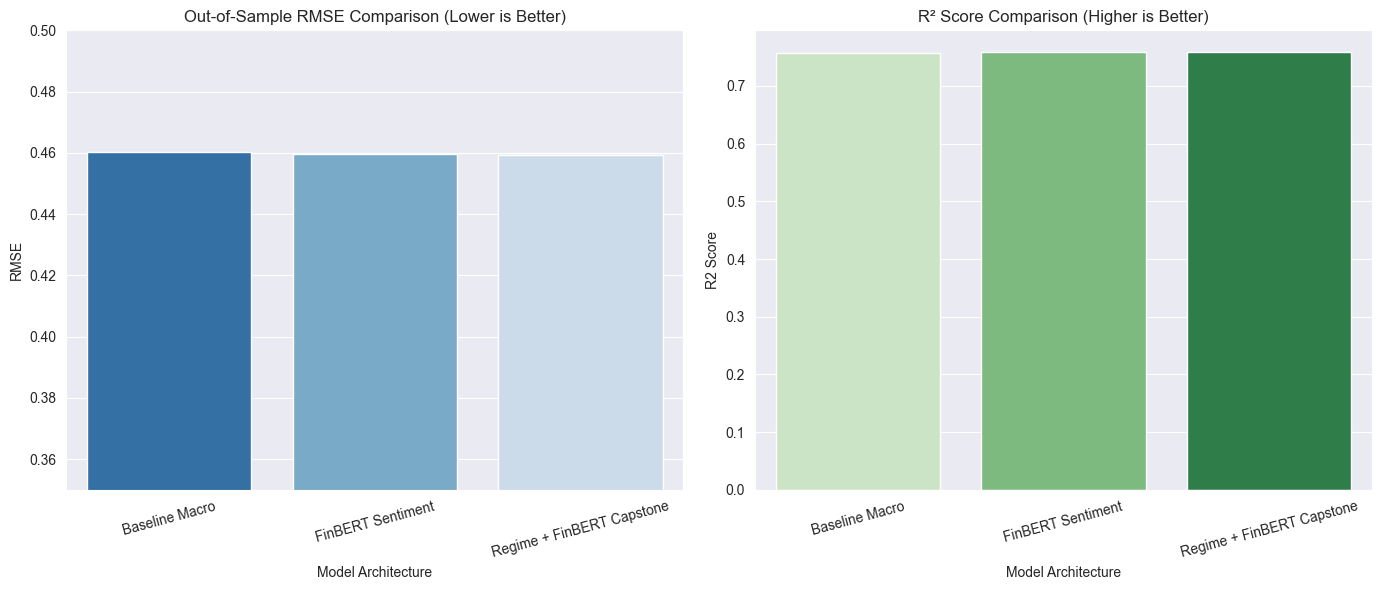

In [6]:
metrics_df = pd.DataFrame({
    'Model Architecture': ['Baseline Macro', 'FinBERT Sentiment', 'Regime + FinBERT Capstone'],
    'RMSE': [rmse_b, rmse_s, rmse_f],
    'R2 Score': [r2_b, r2_s, r2_f]
})

sns.set_style("darkgrid")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=metrics_df, x='Model Architecture', y='RMSE', palette='Blues_r')
plt.title('Out-of-Sample RMSE Comparison (Lower is Better)')
plt.xticks(rotation=15)
plt.ylim(0.35, 0.50)

plt.subplot(1, 2, 2)
sns.barplot(data=metrics_df, x='Model Architecture', y='R2 Score', palette='Greens')
plt.title('R² Score Comparison (Higher is Better)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

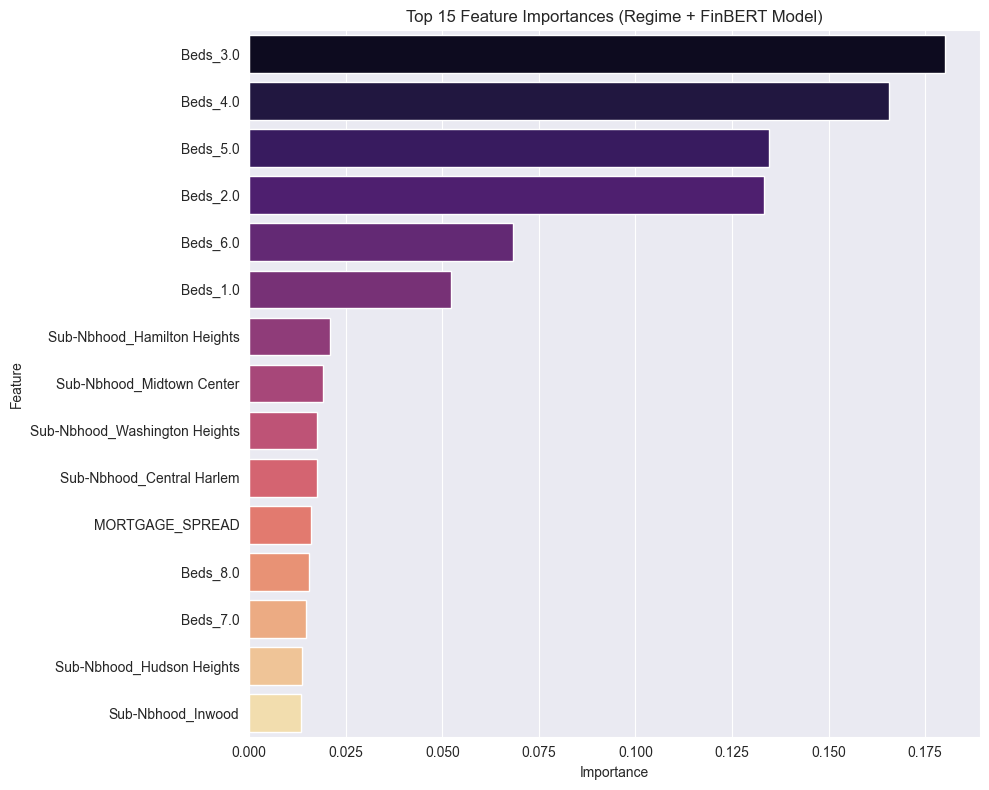

In [7]:
# Feature Importances of the Capstone Strategy
imp_df = pd.DataFrame({'Feature': cols_f, 'Importance': feat_imp_f})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='magma')
plt.title("Top 15 Feature Importances (Regime + FinBERT Model)")
plt.tight_layout()
plt.show()